# Evaluate v4 40epoch Best Checkpoint

`trainer11_reviewed_v4_alldata_40epoch`의 best checkpoint를 RL/DS validation set에서 재평가합니다.

기준 checkpoint:

```text
notebooks/training/logs/trainer11_reviewed_v4_alldata_40epoch/checkpoints/epoch=11-step=042600.ckpt
```

기본값은 `MAX_EVAL_BATCHES=20` 빠른 평가입니다. 최종 보고용 전체 validation은 `MAX_EVAL_BATCHES=None`으로 바꾸고 다시 실행하세요.


In [8]:
from pathlib import Path
import json
import os
import re
import time
from contextlib import nullcontext

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 120)

ROOT = Path("/home/carol/chaeyeon-kim/alpha26")
TRAINER_NB = ROOT / "notebooks" / "training" / "trainer11_reviewed_alldata_40epoch.ipynb"
PROCESSED_DIR = Path("/home/carol/chaeyeon-kim/processed")
RUN_NAME = "trainer11_reviewed_v4_alldata_40epoch"
RUN_LOG_DIR = ROOT / "notebooks" / "training" / "logs" / RUN_NAME
BEST_CKPT = RUN_LOG_DIR / "checkpoints" / "epoch=11-step=042600.ckpt"
LAST_CKPT = RUN_LOG_DIR / "checkpoints" / "last.ckpt"

RESULT_CSV = ROOT / "results" / "v4_40epoch_best_eval_metrics.csv"
FIG_DIR = ROOT / "results" / "v4_40epoch_best_eval_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 2
NUM_WORKERS = 0
MAX_EVAL_BATCHES = None      # 빠른 확인. 전체 validation 평가는 None.
MAX_CHAMFER_POINTS = 2048
USE_AMP = DEVICE == "cuda"

CHECKPOINTS = {
    "best_DS_loss": BEST_CKPT,
    # 필요하면 final/last도 비교하세요.
    # "last": LAST_CKPT,
}

VAL_DATASETS = {
    "RL": PROCESSED_DIR / "validation_run_008.arrow",
    "DS": PROCESSED_DIR / "validation_run_024.arrow",
}

for name, path in CHECKPOINTS.items():
    if not path.exists():
        raise FileNotFoundError(f"{name}: {path}")

print(f"device={DEVICE}")
print(f"trainer={TRAINER_NB}")
print(f"result_csv={RESULT_CSV}")
print("checkpoints:")
for name, path in CHECKPOINTS.items():
    print(f"  {name}: {path}")


device=cuda
trainer=/home/carol/chaeyeon-kim/alpha26/notebooks/training/trainer11_reviewed_alldata_40epoch.ipynb
result_csv=/home/carol/chaeyeon-kim/alpha26/results/v4_40epoch_best_eval_metrics.csv
checkpoints:
  best_DS_loss: /home/carol/chaeyeon-kim/alpha26/notebooks/training/logs/trainer11_reviewed_v4_alldata_40epoch/checkpoints/epoch=11-step=042600.ckpt


## 1. Load Trainer Definitions

학습 노트북의 class/function 정의 셀만 실행합니다. `main()`, 시각화, 학습 실행 셀은 실행하지 않습니다. `timm` backbone은 checkpoint를 로드할 예정이라 `pretrained=False`로 바꿔 외부 다운로드를 피합니다.


In [9]:
def load_trainer_definitions():
    nb = json.loads(TRAINER_NB.read_text())
    namespace = {"__name__": "trainer11_eval_namespace"}

    for cell_idx, cell in enumerate(nb["cells"]):
        if cell.get("cell_type") != "code":
            continue
        src = "".join(cell.get("source", []))
        stripped = src.strip()
        if not stripped:
            continue

        # Stop before the notebook's main()/visualization/log plotting cells.
        if "def main():" in src or "if __name__ == '__main__':" in src:
            break

        src = src.replace("pretrained=True", "pretrained=False")
        exec(compile(src, f"{TRAINER_NB}:cell{cell_idx}", "exec"), namespace)

    return namespace

ns = load_trainer_definitions()
cfg = ns["cfg"]
StreamWindowDataset = ns["StreamWindowDataset"]
WorldModelTrainer = ns["WorldModelTrainer"]

seq_len = cfg.RECEPTIVE_FIELD + cfg.FUTURE_HORIZON
stride = cfg.RECEPTIVE_FIELD * cfg.DATA.SAMPLE_EVERY_N
print(f"Loaded definitions. seq_len={seq_len}, stride={stride}, rf={cfg.RECEPTIVE_FIELD}, fh={cfg.FUTURE_HORIZON}")
print(f"cfg.RUN_NAME={cfg.LOGGING.RUN_NAME}, cfg.STEPS={cfg.STEPS}")


Loaded definitions. seq_len=8, stride=8, rf=4, fh=4
cfg.RUN_NAME=trainer11_reviewed_v4_alldata_40epoch, cfg.STEPS=150000


## 2. Dataset / DataLoader


In [10]:
datasets = {}
dataloaders = {}

for name, arrow_path in VAL_DATASETS.items():
    if not arrow_path.exists():
        raise FileNotFoundError(arrow_path)

    ds = StreamWindowDataset(
        str(arrow_path),
        seq_len=seq_len,
        stride=stride,
        num_streams=BATCH_SIZE,
        sample_every_n=cfg.DATA.SAMPLE_EVERY_N,
        image_input_size=cfg.DATA.IMAGE_INPUT_SIZE,
        rgb_recon_size=cfg.DATA.RGB_RECON_SIZE,
        lidar_size=cfg.DATA.LIDAR_RANGE_VIEW_SIZE,
        frame_step=cfg.DATA.FRAME_STEP,
    )
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=True)
    datasets[name] = ds
    dataloaders[name] = loader
    print(f"{name}: {arrow_path.name}, windows={len(ds)}, batches={len(loader)}")


RL: validation_run_008.arrow, windows=298, batches=149
DS: validation_run_024.arrow, windows=448, batches=224


## 3. Metric Helpers


In [11]:
def parse_step(path):
    match = re.search(r"step=(\d+)", path.name)
    return int(match.group(1)) if match else -1


def parse_epoch(path):
    match = re.search(r"epoch=(\d+)", path.name)
    return int(match.group(1)) if match else -1


def load_model_from_checkpoint(ckpt_path):
    model = WorldModelTrainer(cfg=cfg, lr=cfg.OPTIMIZER.LR, embedding_n_channels=128)
    model.metric_max_chamfer_points = MAX_CHAMFER_POINTS
    checkpoint = torch.load(ckpt_path, map_location="cpu")
    state_dict = checkpoint["state_dict"] if "state_dict" in checkpoint else checkpoint
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    if missing or unexpected:
        print(f"{Path(ckpt_path).name}: missing={len(missing)}, unexpected={len(unexpected)}")
    return model.to(DEVICE).eval(), checkpoint


def mean_dicts(dicts):
    if not dicts:
        return {}
    keys = sorted(set().union(*[d.keys() for d in dicts]))
    out = {}
    for key in keys:
        values = [d[key] for d in dicts if key in d and np.isfinite(d[key])]
        out[key] = float(np.mean(values)) if values else np.nan
    return out


def tensor_dict_to_float(metric_dict):
    out = {}
    for key, value in metric_dict.items():
        if torch.is_tensor(value):
            value = value.detach().float().cpu().item()
        out[key] = float(value)
    return out


@torch.no_grad()
def evaluate_model_on_loader(model, loader, max_batches=MAX_EVAL_BATCHES):
    loss_rows = []
    obs_metric_rows = []
    future_metric_rows = []

    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        batch = {key: value.to(DEVICE) if torch.is_tensor(value) else value for key, value in batch.items()}
        batch = model.prepare_custom_batch(batch)

        amp_context = torch.autocast(device_type=DEVICE, dtype=torch.float16) if USE_AMP else nullcontext()
        with amp_context:
            losses, output, state_dict, losses_imagine, output_imagine = model._observe_and_imagine(batch)

        loss_values = tensor_dict_to_float(losses)
        loss_values["loss"] = float(sum(loss_values.values()))
        loss_rows.append(loss_values)

        batch_rf = model._slice_batch(batch, 0, model.rf)
        obs_metric_rows.append(tensor_dict_to_float(model.compute_eval_metrics(batch_rf, output)))

        if output_imagine is not None and model.fh > 0:
            batch_fh = model._slice_batch(batch, model.rf, model.rf + model.fh)
            future_metric_rows.append(tensor_dict_to_float(model.compute_eval_metrics(batch_fh, output_imagine, prefix="future_")))

    return {
        "loss": mean_dicts(loss_rows),
        "observed": mean_dicts(obs_metric_rows),
        "future": mean_dicts(future_metric_rows),
        "num_batches": len(loss_rows),
    }


def flatten_eval_result(result):
    flat = {"num_batches": result["num_batches"]}
    for key, value in result["loss"].items():
        flat[f"loss_{key}"] = value
    for key, value in result["observed"].items():
        flat[f"observed_{key}"] = value
    for key, value in result["future"].items():
        flat[f"future_{key}"] = value
    return flat


## 4. Run Evaluation


In [12]:
rows = []
start_time = time.time()

for ckpt_name, ckpt_path in CHECKPOINTS.items():
    print(f"loading {ckpt_name}: {ckpt_path.name}")
    model, checkpoint = load_model_from_checkpoint(ckpt_path)

    for dataset_name, loader in dataloaders.items():
        print(f"  evaluating {dataset_name}...", end=" ")
        result = evaluate_model_on_loader(model, loader, max_batches=MAX_EVAL_BATCHES)
        out = {
            "run_name": RUN_NAME,
            "checkpoint_name": ckpt_name,
            "checkpoint": ckpt_path.name,
            "checkpoint_path": str(ckpt_path),
            "epoch": parse_epoch(ckpt_path),
            "step": parse_step(ckpt_path),
            "dataset": dataset_name,
            "global_step": int(checkpoint.get("global_step", parse_step(ckpt_path))) if isinstance(checkpoint, dict) else parse_step(ckpt_path),
            "max_eval_batches": MAX_EVAL_BATCHES if MAX_EVAL_BATCHES is not None else "all",
        }
        out.update(flatten_eval_result(result))
        rows.append(out)
        print(f"done, batches={result['num_batches']}")

    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

metrics_df = pd.DataFrame(rows).sort_values(["checkpoint_name", "dataset"])
metrics_df.to_csv(RESULT_CSV, index=False)
elapsed_min = (time.time() - start_time) / 60
print(f"Saved {RESULT_CSV}. elapsed={elapsed_min:.1f} min")
display(metrics_df)


loading best_DS_loss: epoch=11-step=042600.ckpt
  evaluating RL... done, batches=149
  evaluating DS... done, batches=224
Saved /home/carol/chaeyeon-kim/alpha26/results/v4_40epoch_best_eval_metrics.csv. elapsed=3.9 min


,run_name,checkpoint_name,checkpoint,checkpoint_path,epoch,step,dataset,global_step,max_eval_batches,num_batches,loss_future_lidar_depth_2,loss_future_lidar_depth_4,loss_future_lidar_empty_depth_2,loss_future_lidar_empty_depth_4,loss_future_lidar_xyz_2,loss_future_lidar_xyz_4,loss_future_rgb_2,loss_future_rgb_4,loss_lidar_depth_2,loss_lidar_depth_4,loss_lidar_empty_depth_2,loss_lidar_empty_depth_4,loss_lidar_xyz_2,loss_lidar_xyz_4,loss_loss,loss_probabilistic,loss_rgb_2,loss_rgb_4,observed_lidar_chamfer_xyz,observed_lidar_range_mae,observed_lidar_xyz_euclidean,observed_rgb_psnr,future_future_lidar_chamfer_xyz,future_future_lidar_range_mae,future_future_lidar_xyz_euclidean,future_future_rgb_psnr
1,trainer11_reviewed_v4_alldata_40epoch,best_DS_loss,epoch=11-step=042600.ckpt,/home/carol/chaeyeon-kim/alpha26/notebooks/tra...,11,42600,DS,42600,all,224,1.339859,0.679861,0.238053,0.116433,2.407428,1.226495,0.104956,0.051350,1.342774,0.682261,0.236383,0.114569,2.456099,1.257488,12.671155,0.258622,0.106460,0.052064,2.049662,13.427738,4.384228,11.732169,2.027430,13.398588,4.375143,11.81070
0,trainer11_reviewed_v4_alldata_40epoch,best_DS_loss,epoch=11-step=042600.ckpt,/home/carol/chaeyeon-kim/alpha26/notebooks/tra...,11,42600,RL,42600,all,149,1.301426,0.660755,0.231146,0.111975,3.115947,1.572006,0.104052,0.050914,1.306636,0.663924,0.225288,0.108589,3.098734,1.572078,14.581163,0.302262,0.104343,0.051088,2.195325,13.066359,5.063868,12.005234,2.145977,13.014262,5.063771,12.00228


## 5. Compact Summary


In [13]:
summary_cols = [
    "checkpoint_name", "dataset", "global_step", "num_batches",
    "loss_loss",
    "observed_rgb_psnr", "future_future_rgb_psnr",
    "observed_lidar_chamfer_xyz", "future_future_lidar_chamfer_xyz",
    "observed_lidar_range_mae", "future_future_lidar_range_mae",
]
summary = metrics_df[[col for col in summary_cols if col in metrics_df.columns]].copy()
display(summary)


,checkpoint_name,dataset,global_step,num_batches,loss_loss,observed_rgb_psnr,future_future_rgb_psnr,observed_lidar_chamfer_xyz,future_future_lidar_chamfer_xyz,observed_lidar_range_mae,future_future_lidar_range_mae
1,best_DS_loss,DS,42600,224,12.671155,11.732169,11.81070,2.049662,2.027430,13.427738,13.398588
0,best_DS_loss,RL,42600,149,14.581163,12.005234,12.00228,2.195325,2.145977,13.066359,13.014262


## 6. Bar Plots


Saved: /home/carol/chaeyeon-kim/alpha26/results/v4_40epoch_best_eval_figures/v4_40epoch_best_eval_summary.png


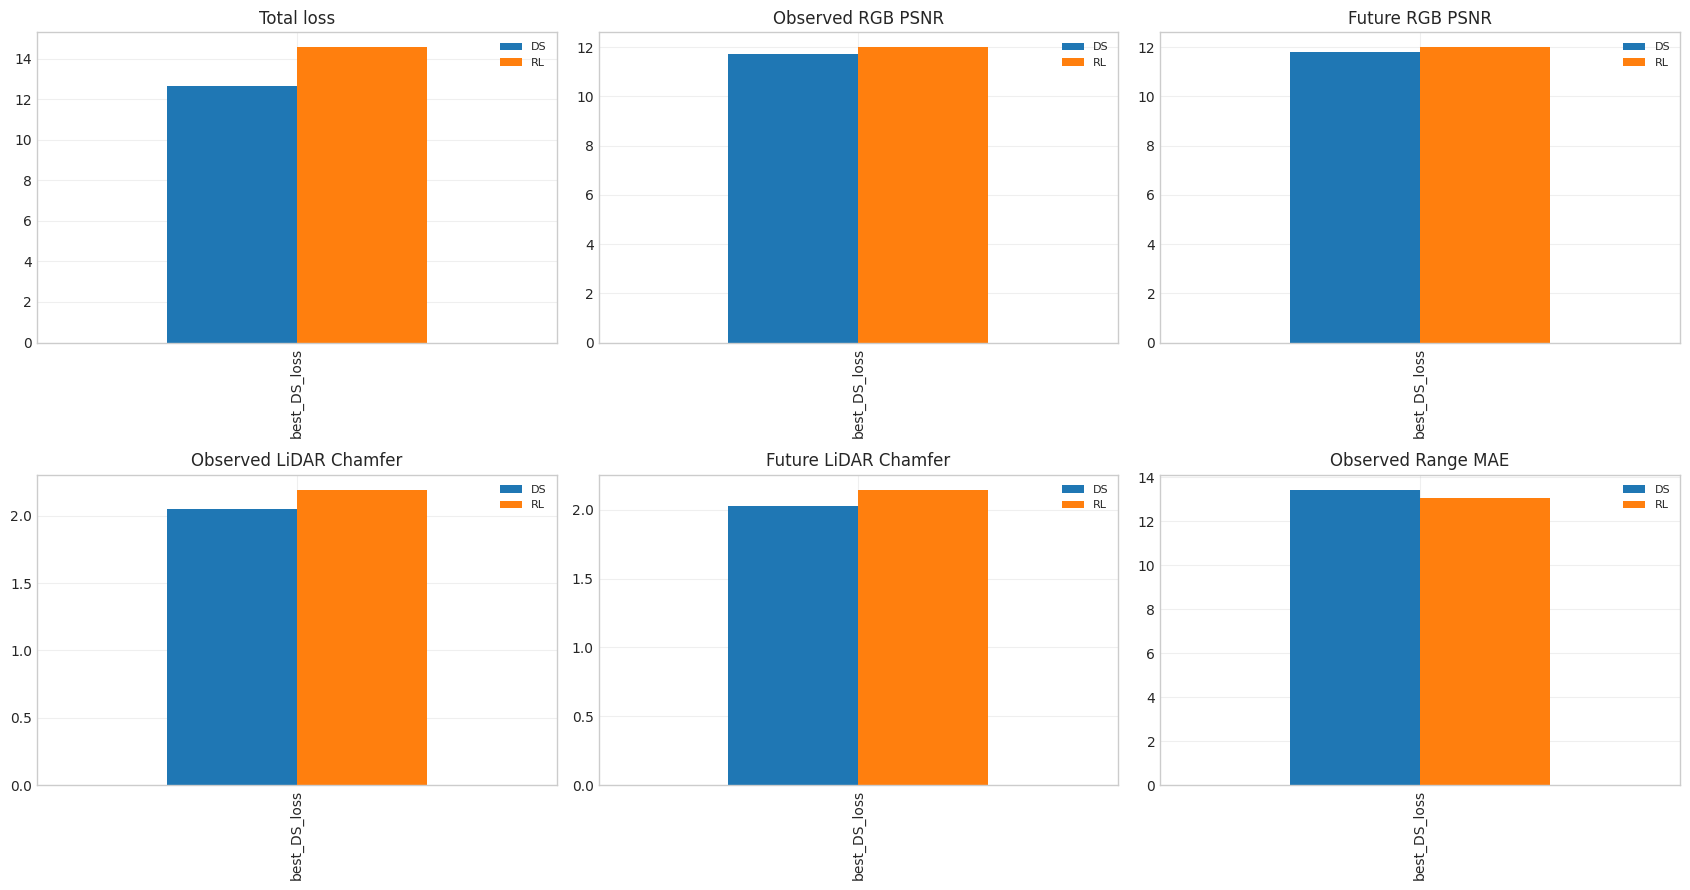

In [14]:
plot_cols = [
    ("loss_loss", "Total loss", False),
    ("observed_rgb_psnr", "Observed RGB PSNR", True),
    ("future_future_rgb_psnr", "Future RGB PSNR", True),
    ("observed_lidar_chamfer_xyz", "Observed LiDAR Chamfer", False),
    ("future_future_lidar_chamfer_xyz", "Future LiDAR Chamfer", False),
    ("observed_lidar_range_mae", "Observed Range MAE", False),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.ravel()
for ax, (col, title, higher) in zip(axes, plot_cols):
    if col not in metrics_df.columns:
        ax.axis("off")
        continue
    data = metrics_df.pivot(index="checkpoint_name", columns="dataset", values=col)
    data.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
out = FIG_DIR / "v4_40epoch_best_eval_summary.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()


## 7. Notes

- `MAX_EVAL_BATCHES=20`은 학습 중 validation과 맞춘 빠른 비교입니다.
- 최종 보고용으로는 첫 셀에서 `MAX_EVAL_BATCHES=None`으로 바꾼 뒤 전체 validation 평가를 다시 실행하세요.
- `CHECKPOINTS`에 `"last": LAST_CKPT`를 추가하면 best와 final checkpoint를 같은 표에서 비교할 수 있습니다.
